In [1]:
from utils.consts import *
from utils. plotting import *
from data_reader_babalit import *
from nonlegality_analyser import *
import random

In [2]:
users = [7,9,15,16,20,21,23,29, 35]
balabit_reader = DataReaderBalabit(BALABIT, users, True, limit = 600)
balabit_reader.processDataWithoutLabels()



In [3]:

path = balabit_reader.getFile()
balabitAnalyser = nonLegalityAnalyser(path)
print(balabitAnalyser.countActions())

type_of_action    1    3   4
userid                      
7               261  476  64
9               325  485  68
15              194  382  59
16              205  359  71
20              488  489  60
21              215  337  60
23              206  432  34
29              104  391  67
35              244  381  59


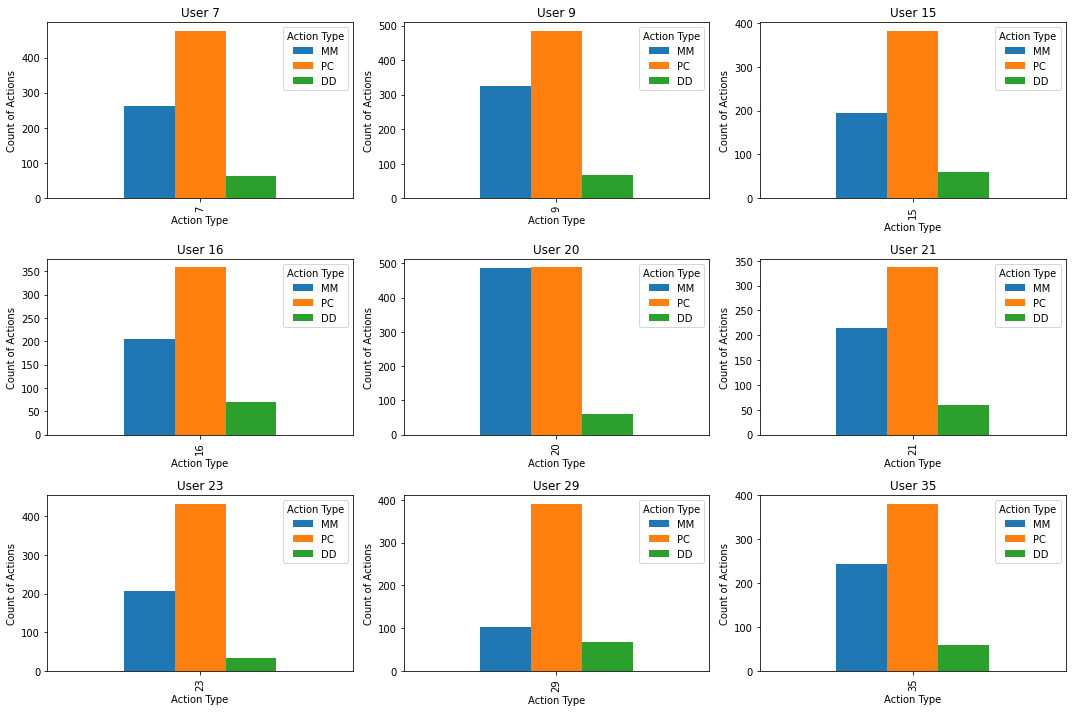

In [4]:
balabitAnalyser.plotActionHistograms()

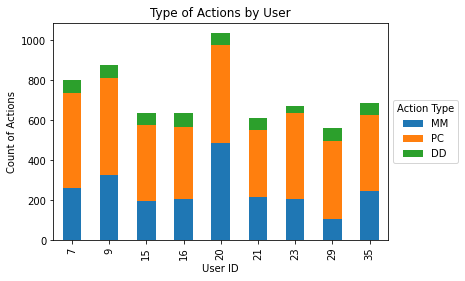

In [5]:
balabitAnalyser.plotTypeOfActions(True)

In [6]:
balabitAnalyser.df

,type_of_action,traveled_distance_pixel,elapsed_time,direction_of_movement,straightness,num_points,sum_of_angles,mean_curv,sd_curv,max_curv,...,mean_a,sd_a,max_a,min_a,mean_jerk,sd_jerk,max_jerk,min_jerk,a_beg_time,userid
0,3,798.225271,0.921,7,0.824363,8,-10.178816,-0.018615,0.034165,0.004564,...,-2314.139918,12628.171566,12373.662905,-28991.748457,-16087.091640,2.137862e+05,2.807202e+05,-4.400576e+05,0.234,15
1,3,928.351656,1.170,7,0.946649,12,-8.068119,-0.048395,0.123927,0.019558,...,4819.630196,19180.145671,51497.364847,-17902.080003,402405.082761,1.462335e+06,4.788644e+06,-4.624385e+05,0.104,15
2,3,1618.774595,2.355,3,0.510264,21,17.159243,-0.010018,0.157139,0.451858,...,2268.012804,13393.213527,42448.436326,-14856.484996,183023.383110,1.059901e+06,4.591625e+06,-6.722202e+05,0.218,15
3,3,204.875367,1.061,3,0.701577,9,4.733061,0.124663,0.428283,1.107149,...,559.243309,4934.530363,11168.793558,-6557.631722,7340.337498,5.985349e+04,1.009243e+05,-1.136309e+05,0.218,15
4,3,39.223137,1.700,1,0.993003,6,4.524354,0.091940,0.101128,0.394983,...,135.708701,397.655153,820.357911,-251.158608,979.601466,4.329883e+03,7.995918e+03,-4.043459e+03,0.296,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6511,3,636.453166,1.170,0,0.952371,107,62.503732,0.012838,0.214185,0.785398,...,4075.234881,28402.773679,143178.210633,-54660.306887,628534.312592,4.275028e+06,1.431782e+07,-1.059732e+07,0.010,9
6512,1,98.685410,0.296,5,0.978262,24,-51.499459,0.006849,0.198231,0.785398,...,3688.073078,22522.814691,84852.813742,-22524.220792,503118.701547,3.117554e+06,8.485281e+06,-6.711065e+06,0.010,9
6513,1,174.173153,0.422,4,0.979092,39,-81.441103,0.164614,0.930056,5.497787,...,2790.331024,20751.308389,52638.022839,-33808.172191,393208.232270,2.926201e+06,7.468815e+06,-5.402887e+06,0.026,9
6514,3,285.248702,1.030,7,0.739647,71,19.400664,0.015966,0.273254,1.570796,...,3181.320474,18622.272122,49732.915632,-29406.022223,438306.756254,2.915647e+06,7.531631e+06,-4.949747e+06,0.016,9


In [7]:
from RFmodel import *

User 7 is being analyzed:
CV Accuracy: 0.90 (+/- 0.04)
Test Accuracy: 0.85
7: 0.9969149127540925 threshold: 0.48000000000095533
User 9 is being analyzed:
CV Accuracy: 0.94 (+/- 0.05)
Test Accuracy: 0.90
9: 0.999851097412073 threshold: 0.4799999999978416
User 15 is being analyzed:
CV Accuracy: 0.75 (+/- 0.08)
Test Accuracy: 0.74
15: 0.9786525208041408 threshold: 0.4783333333333334
User 16 is being analyzed:
CV Accuracy: 0.72 (+/- 0.10)
Test Accuracy: 0.72
16: 0.9716455044612217 threshold: 0.5525000000004402
User 20 is being analyzed:
CV Accuracy: 0.83 (+/- 0.04)
Test Accuracy: 0.80
20: 0.9908755263102215 threshold: 0.489476837061189
User 21 is being analyzed:
CV Accuracy: 0.72 (+/- 0.10)
Test Accuracy: 0.72
21: 0.9485893320162982 threshold: 0.5012078651686767
User 23 is being analyzed:
CV Accuracy: 0.73 (+/- 0.06)
Test Accuracy: 0.73
23: 0.9877177767007627 threshold: 0.4875
User 29 is being analyzed:
CV Accuracy: 0.79 (+/- 0.06)
Test Accuracy: 0.75
29: 0.995775320524595 threshold: 0.465

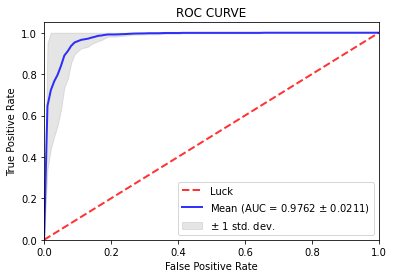

In [8]:
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}

for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)


In [9]:
from SVMmodel import *

User 7 is being analyzed:
CV Accuracy: 0.82 (+/- 0.10)
Test Accuracy: 0.78
7: 0.9718793603091124 threshold: 0.4590360510657656
User 9 is being analyzed:
CV Accuracy: 0.87 (+/- 0.07)
Test Accuracy: 0.88
9: 0.9993465993465993 threshold: 0.4775082524788054
User 15 is being analyzed:
CV Accuracy: 0.74 (+/- 0.10)
Test Accuracy: 0.71
15: 0.9726571494358738 threshold: 0.5487564412509167
User 16 is being analyzed:
CV Accuracy: 0.67 (+/- 0.09)
Test Accuracy: 0.71
16: 0.9488689982555979 threshold: 0.4870741416249484
User 20 is being analyzed:
CV Accuracy: 0.80 (+/- 0.06)
Test Accuracy: 0.80
20: 0.959441165894621 threshold: 0.5627235721159132
User 21 is being analyzed:
CV Accuracy: 0.72 (+/- 0.10)
Test Accuracy: 0.70
21: 0.946572425074848 threshold: 0.533163550208874
User 23 is being analyzed:
CV Accuracy: 0.70 (+/- 0.09)
Test Accuracy: 0.75
23: 0.9663880581754978 threshold: 0.49672514054375966
User 29 is being analyzed:
CV Accuracy: 0.74 (+/- 0.10)
Test Accuracy: 0.71
29: 0.9089673413908379 thre

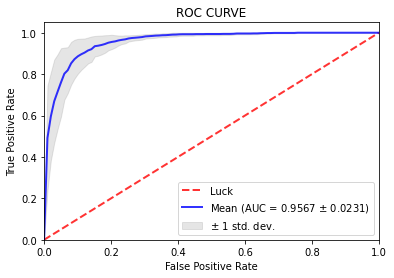

In [10]:
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}

for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = SVMModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)

In [11]:
legalUser = random.choice(users)
dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
X = dataset[:, 0:-1]
y = dataset[:, -1]
X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
model = RFModel(dataset, users)
feature_importance = model.calculateFeatureImportance(X_train, y_train, X_validation)
df1 = balabitAnalyser.returnDataframe()


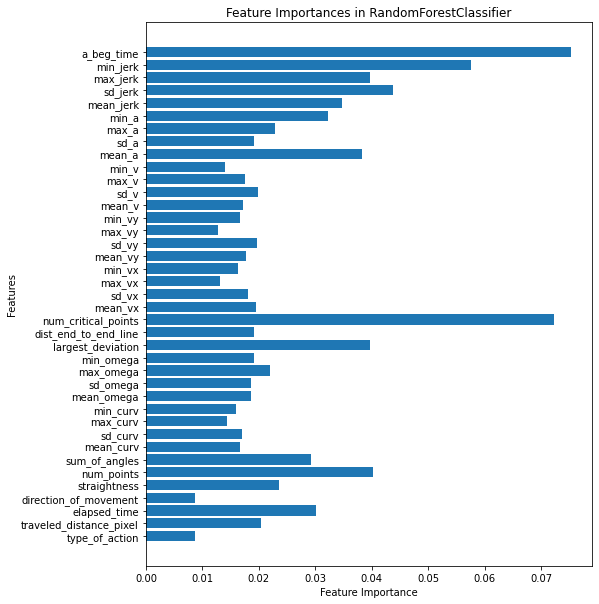

In [12]:
model.plotFeatureImportance(feature_importance, X, df1)

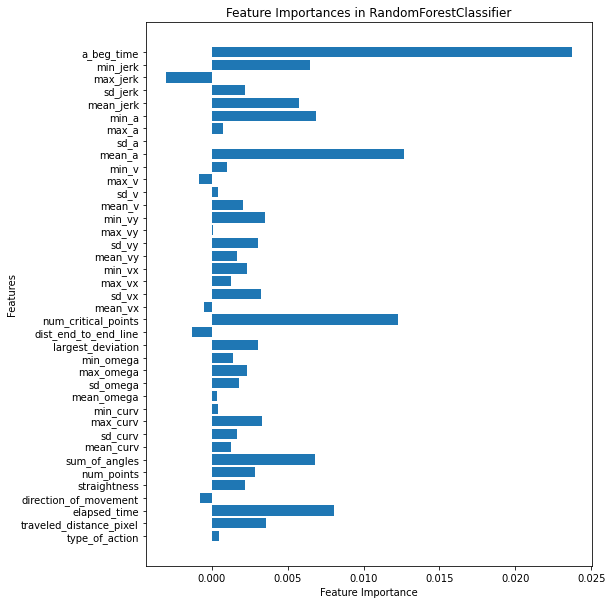

In [13]:
permutationImportance = model.calculatePermutationImportance(X_train, y_train, X_validation, y_validation)
model.plotFeatureImportance(permutationImportance, X, df1)

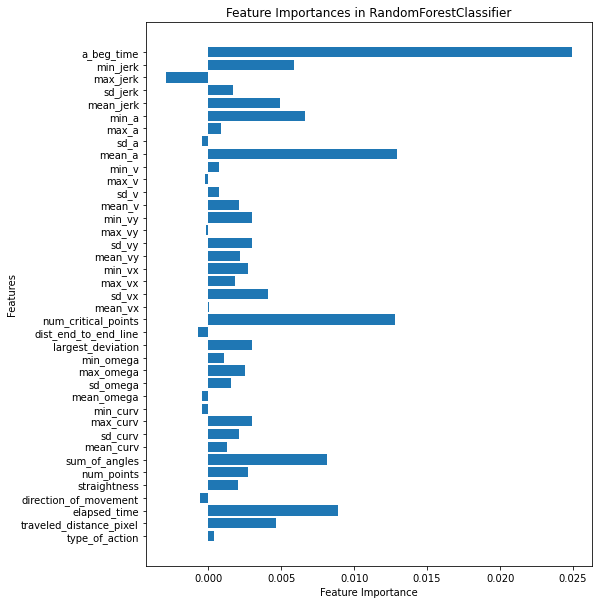

In [14]:
permutationImportance = model.calculatePermutationImportance1(X_train, y_train, X_validation, y_validation)
model.plotFeatureImportance(permutationImportance, X, df1)

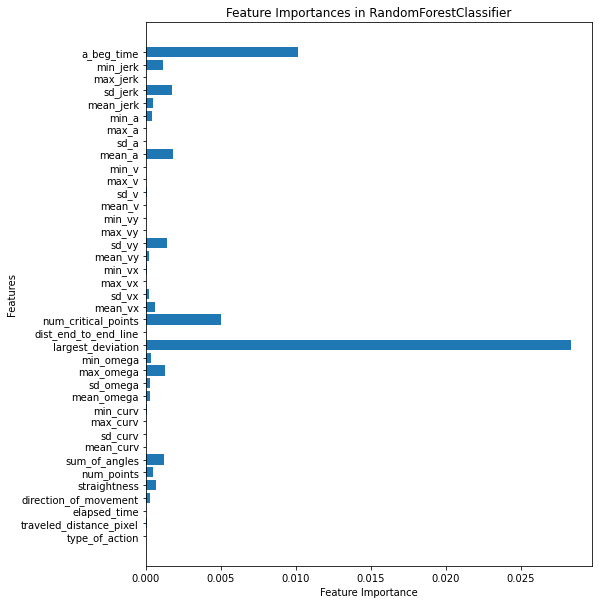

In [15]:
permutationImportance = model.calculatePermutationImportance2(X_train, y_train, X_validation, y_validation)
model.plotFeatureImportance(permutationImportance, X, df1)